# Notebook 03 - SHAP agreement and explanation faithfulness

Explains the calibrated models from NB02 and tests two things the trust framing depends on:
whether the three architectures agree on *why* a student is flagged, and whether those
explanations are *faithful* - overall and within protected groups.

**What it computes:**

* **SHAP per model** on a stratified ~1,500-row sample of each cutoff's test split.
  TreeExplainer for random forest and gradient boosting; closed-form LinearExplainer for
  logistic regression.
* **Cross-model agreement (C2):** Spearman and Kendall rank correlation of the mean-|SHAP|
  feature rankings between each model pair, per cutoff, with B=1000 bootstrap CIs.
* **Faithfulness (C3):** deletion and insertion AOPC - remove (or restore) the top features
  per instance and watch the prediction collapse (or recover). Reported overall, and the
  deletion AOPC is split by `disability` and by `imd_band` (deprived vs affluent) with
  bootstrap CIs on the gap. That subgroup split is the C6 trust-equity angle: a faithful
  explanation overall can still be less faithful for the students most at risk.

**Inputs (from NB02):** `models_week{w}.joblib`, `model_ready_week{w}` (uses the `split`
column so SHAP runs on the identical test rows).

**Outputs:** `results/processed/shap_importance_week{w}`, `results/agreement_summary.csv`,
`results/faithfulness_summary.csv`, and figures in `results/figures/`.

## 0. Setup

In [1]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'shap'])
    import shap

from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = Path('/content/drive/MyDrive/StudentEWS_Research/student-ews-research')
except Exception:
    ROOT = Path('.')

PROC   = ROOT / 'results' / 'processed'
MODELS = ROOT / 'results' / 'models'
FIG    = ROOT / 'results' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

CUTOFF_WEEKS = [5, 10, 15, 25]
SEED   = 42
N_SHAP = 1500            # stratified test-set sample for SHAP / faithfulness
B_BOOT = 1000            # bootstrap resamples
STEPS  = [1, 2, 3, 5, 8, 12]
MODEL_ORDER = ['logreg', 'rf', 'hgb']

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau

rng_global = np.random.default_rng(SEED)

## 1. Helpers

In [3]:
def load_ready(w):
    p = PROC / f'model_ready_week{w}.parquet'
    c = PROC / f'model_ready_week{w}.csv'
    return pd.read_parquet(p) if p.exists() else pd.read_csv(c)

def save_table(df, stem):
    try:
        path = stem.with_suffix('.parquet'); df.to_parquet(path, index=False)
    except Exception:
        path = stem.with_suffix('.csv'); df.to_csv(path, index=False)
    return path

def stratified_sample(df_test, n_target, seed):
    if len(df_test) <= n_target:
        return df_test.reset_index(drop=True)
    frac = n_target / len(df_test)
    return (df_test.groupby('at_risk', group_keys=False)
                   .sample(frac=frac, random_state=seed)
                   .reset_index(drop=True))

def shap_matrix(sv):
    # Normalise any SHAP output to a 2D (n_rows, n_features) positive-class array.
    if isinstance(sv, list):
        sv = sv[1] if len(sv) == 2 else sv[-1]
    sv = np.asarray(sv)
    if sv.ndim == 3:
        sv = sv[:, :, 1] if sv.shape[-1] == 2 else sv[:, :, -1]
    return sv

def compute_shap(name, est, Xdf):
    if name == 'logreg':
        scaler, lr = est.named_steps['scaler'], est.named_steps['clf']
        bg = scaler.transform(Xdf)
        ex = shap.LinearExplainer(lr, bg)
        return shap_matrix(ex.shap_values(scaler.transform(Xdf)))
    try:
        ex = shap.TreeExplainer(est)
        return shap_matrix(ex.shap_values(Xdf, check_additivity=False))
    except Exception:
        ex = shap.Explainer(est.predict_proba, Xdf)
        return shap_matrix(ex(Xdf).values)

def make_predict_fn(est, features):
    def f(Xnp):
        return est.predict_proba(pd.DataFrame(Xnp, columns=features))[:, 1]
    return f

def aopc(predict_fn, Xnp, abs_shap, steps):
    # Per-instance deletion/insertion AOPC + mean curves (for plotting).
    n, F = Xnp.shape
    base = Xnp.mean(axis=0)
    order = np.argsort(-abs_shap, axis=1)        # most important feature first
    rows = np.arange(n)
    p0 = predict_fn(Xnp)
    Xbase = np.tile(base, (n, 1))
    pbase = predict_fn(Xbase)
    del_curve, ins_curve = [p0.mean()], [pbase.mean()]
    del_pi, ins_pi = np.zeros(n), np.zeros(n)
    for k in steps:
        Xd, Xi = Xnp.copy(), Xbase.copy()
        cols = order[:, :k]
        for j in range(k):
            Xd[rows, cols[:, j]] = base[cols[:, j]]
            Xi[rows, cols[:, j]] = Xnp[rows, cols[:, j]]
        pd_, pi_ = predict_fn(Xd), predict_fn(Xi)
        del_curve.append(pd_.mean()); ins_curve.append(pi_.mean())
        del_pi += (p0 - pd_); ins_pi += (pi_ - pbase)
    return del_pi / len(steps), ins_pi / len(steps), np.array(del_curve), np.array(ins_curve)

def _stat(res):
    return float(res.statistic) if hasattr(res, 'statistic') else float(res[0])

def boot_agreement(Ma, Mb, B, seed):
    r = np.random.default_rng(seed)
    n = Ma.shape[0]
    sp, kt = [], []
    for _ in range(B):
        idx = r.integers(0, n, n)
        ia, ib = np.abs(Ma[idx]).mean(0), np.abs(Mb[idx]).mean(0)
        sp.append(_stat(spearmanr(ia, ib)))
        kt.append(_stat(kendalltau(ia, ib)))
    return (np.nanpercentile(sp, [2.5, 97.5]), np.nanpercentile(kt, [2.5, 97.5]))

def boot_gap(a, b, B, seed):
    # CI for mean(a) - mean(b).
    if len(a) == 0 or len(b) == 0:
        return (np.nan, np.nan)
    r = np.random.default_rng(seed)
    d = [r.choice(a, len(a), True).mean() - r.choice(b, len(b), True).mean() for _ in range(B)]
    return tuple(np.percentile(d, [2.5, 97.5]))

## 2. SHAP, agreement, and faithfulness per cutoff

In [4]:
imp_tables, agreement_rows, faith_rows = {}, [], []
demo15 = {}

for w in CUTOFF_WEEKS:
    bundle = joblib.load(MODELS / f'models_week{w}.joblib')
    FEATURES = bundle['features']

    ready = load_ready(w)
    test = ready[ready['split'] == 'test']
    samp = stratified_sample(test, N_SHAP, SEED)

    Xdf = samp[FEATURES].reset_index(drop=True)
    Xnp = Xdf.to_numpy(dtype=float)
    disab = samp['disability'].to_numpy()
    imd_ord = pd.to_numeric(samp['imd_band_ord'], errors='coerce').to_numpy()

    imp, Mrows, del_pi_by, curves = {}, {}, {}, {}
    for name in MODEL_ORDER:
        est = bundle['models'][name]['estimator']
        M = compute_shap(name, est, Xdf)
        Mrows[name] = M
        imp[name] = np.abs(M).mean(axis=0)
        del_pi, ins_pi, dcurve, icurve = aopc(make_predict_fn(est, FEATURES), Xnp, np.abs(M), STEPS)
        del_pi_by[name] = del_pi
        curves[name] = dcurve

        dep = del_pi[np.isin(imd_ord, [0, 1, 2])]
        aff = del_pi[np.isin(imd_ord, [7, 8, 9])]
        yv, nv = del_pi[disab == 'Y'], del_pi[disab == 'N']
        gd_lo, gd_hi = boot_gap(yv, nv, B_BOOT, SEED)
        gi_lo, gi_hi = boot_gap(dep, aff, B_BOOT, SEED)
        faith_rows.append({
            'cutoff_week': w, 'model': name,
            'del_aopc': del_pi.mean(), 'ins_aopc': ins_pi.mean(),
            'del_aopc_disab_Y': yv.mean() if len(yv) else np.nan,
            'del_aopc_disab_N': nv.mean() if len(nv) else np.nan,
            'gap_disab_Y_minus_N': (yv.mean() - nv.mean()) if len(yv) and len(nv) else np.nan,
            'gap_disab_lo': gd_lo, 'gap_disab_hi': gd_hi,
            'del_aopc_deprived': dep.mean() if len(dep) else np.nan,
            'del_aopc_affluent': aff.mean() if len(aff) else np.nan,
            'gap_imd_deprived_minus_affluent': (dep.mean() - aff.mean()) if len(dep) and len(aff) else np.nan,
            'gap_imd_lo': gi_lo, 'gap_imd_hi': gi_hi,
        })

    imp_df = pd.DataFrame({'feature': FEATURES, **{f'imp_{k}': imp[k] for k in MODEL_ORDER}})
    imp_tables[w] = imp_df
    save_table(imp_df, PROC / f'shap_importance_week{w}')

    for a, b in [('logreg', 'rf'), ('logreg', 'hgb'), ('rf', 'hgb')]:
        (sp_lo, sp_hi), (kt_lo, kt_hi) = boot_agreement(Mrows[a], Mrows[b], B_BOOT, SEED)
        agreement_rows.append({
            'cutoff_week': w, 'pair': f'{a}-{b}',
            'spearman': _stat(spearmanr(imp[a], imp[b])), 'spearman_lo': sp_lo, 'spearman_hi': sp_hi,
            'kendall': _stat(kendalltau(imp[a], imp[b])), 'kendall_lo': kt_lo, 'kendall_hi': kt_hi,
        })

    if w == 15:
        demo15 = {'imp': imp_df, 'curves': curves, 'del_pi': del_pi_by['hgb'], 'imd_ord': imd_ord}
    print(f'week {w:2d}: SHAP + agreement + faithfulness done ({len(samp)} rows sampled)')

week  5: SHAP + agreement + faithfulness done (1500 rows sampled)
week 10: SHAP + agreement + faithfulness done (1500 rows sampled)
week 15: SHAP + agreement + faithfulness done (1500 rows sampled)
week 25: SHAP + agreement + faithfulness done (1500 rows sampled)


## 3. Summary tables

In [5]:
agreement = pd.DataFrame(agreement_rows)
faith = pd.DataFrame(faith_rows)
agreement.to_csv(ROOT / 'results' / 'agreement_summary.csv', index=False)
faith.to_csv(ROOT / 'results' / 'faithfulness_summary.csv', index=False)

print('Cross-model SHAP agreement (Spearman, with 95% CI):')
print(agreement[['cutoff_week', 'pair', 'spearman', 'spearman_lo', 'spearman_hi']]
      .round(3).to_string(index=False))
print('\nFaithfulness - deletion AOPC and the imd deprived-minus-affluent gap:')
print(faith[['cutoff_week', 'model', 'del_aopc',
             'gap_imd_deprived_minus_affluent', 'gap_imd_lo', 'gap_imd_hi']]
      .round(4).to_string(index=False))

Cross-model SHAP agreement (Spearman, with 95% CI):
 cutoff_week       pair  spearman  spearman_lo  spearman_hi
           5  logreg-rf     0.474        0.458        0.493
           5 logreg-hgb     0.364        0.352        0.390
           5     rf-hgb     0.913        0.905        0.924
          10  logreg-rf     0.560        0.542        0.578
          10 logreg-hgb     0.531        0.513        0.559
          10     rf-hgb     0.742        0.719        0.767
          15  logreg-rf     0.696        0.667        0.704
          15 logreg-hgb     0.570        0.553        0.601
          15     rf-hgb     0.670        0.659        0.708
          25  logreg-rf     0.735        0.722        0.753
          25 logreg-hgb     0.653        0.639        0.665
          25     rf-hgb     0.789        0.770        0.799

Faithfulness - deletion AOPC and the imd deprived-minus-affluent gap:
 cutoff_week  model  del_aopc  gap_imd_deprived_minus_affluent  gap_imd_lo  gap_imd_hi
          

## 4. Figures (saved to results/figures/)

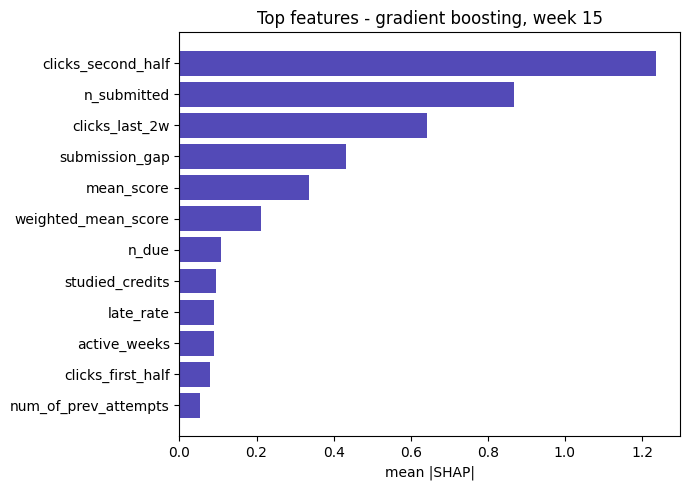

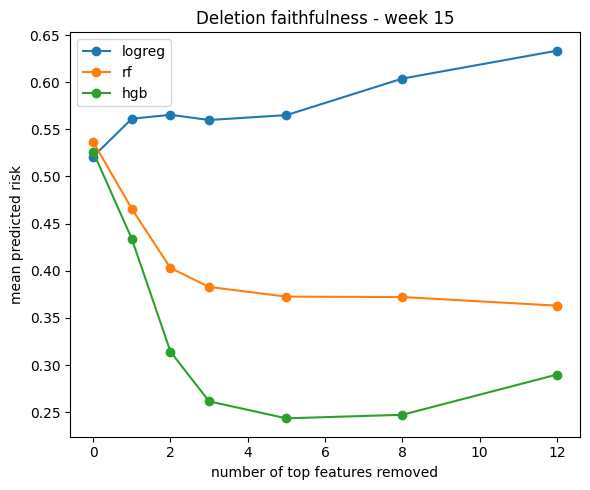

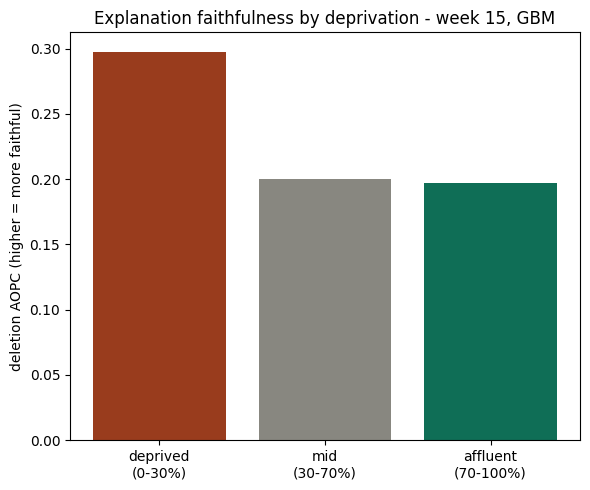

saved 3 figures to /content/drive/MyDrive/StudentEWS_Research/student-ews-research/results/figures


In [6]:
if demo15:
    # (a) SHAP importance - top 12 features, gradient boosting, week 15
    d = demo15['imp'].sort_values('imp_hgb', ascending=False).head(12).iloc[::-1]
    plt.figure(figsize=(7, 5))
    plt.barh(d['feature'], d['imp_hgb'], color='#534AB7')
    plt.xlabel('mean |SHAP|'); plt.title('Top features - gradient boosting, week 15')
    plt.tight_layout(); plt.savefig(FIG / 'fig_shap_importance_week15.png', dpi=300, bbox_inches='tight')
    plt.show()

    # (b) Deletion curves - all three models, week 15
    xs = [0] + STEPS
    plt.figure(figsize=(6, 5))
    for name, c in demo15['curves'].items():
        plt.plot(xs, c, marker='o', label=name)
    plt.xlabel('number of top features removed'); plt.ylabel('mean predicted risk')
    plt.title('Deletion faithfulness - week 15'); plt.legend()
    plt.tight_layout(); plt.savefig(FIG / 'fig_deletion_curves_week15.png', dpi=300, bbox_inches='tight')
    plt.show()

    # (c) Deletion AOPC by imd group - gradient boosting, week 15 (the C6 view)
    dp = demo15['del_pi']; io = demo15['imd_ord']
    groups = {'deprived\n(0-30%)': np.isin(io, [0, 1, 2]),
              'mid\n(30-70%)': np.isin(io, [3, 4, 5, 6]),
              'affluent\n(70-100%)': np.isin(io, [7, 8, 9])}
    labels = list(groups); vals = [dp[m].mean() if m.sum() else np.nan for m in groups.values()]
    plt.figure(figsize=(6, 5))
    plt.bar(labels, vals, color=['#993C1D', '#888780', '#0F6E56'])
    plt.ylabel('deletion AOPC (higher = more faithful)')
    plt.title('Explanation faithfulness by deprivation - week 15, GBM')
    plt.tight_layout(); plt.savefig(FIG / 'fig_faithfulness_by_imd_week15.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('saved 3 figures to', FIG)
else:
    print('Week 15 not in CUTOFF_WEEKS; no demo figures.')

In [7]:
import os, glob
os.chdir('/content/drive/MyDrive/StudentEWS_Research/student-ews-research')
!pip install python-docx -q

import pandas as pd, numpy as np
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
from docx import Document
from docx.shared import Inches, Pt
from datetime import date

FIG = 'results/figures'; os.makedirs(FIG, exist_ok=True)
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

def load(stem):
    for e in ('.parquet', '.csv'):
        if os.path.exists(stem + e):
            return pd.read_parquet(stem + e) if e == '.parquet' else pd.read_csv(stem + e)
    return None

# ---------- regenerate NB01/NB02 figures from real data (idempotent) ----------
df = load('results/processed/features_week5')
if df is not None:
    overall = df['at_risk'].mean()
    order = ['0-10%','10-20','20-30%','30-40%','40-50%','50-60%','60-70%','70-80%','80-90%','90-100%','?']
    ir = df.groupby('imd_band')['at_risk'].mean()
    ir = ir.reindex([b for b in order if b in ir.index] + [b for b in ir.index if b not in order])
    plt.figure(figsize=(7.2,4)); plt.bar(ir.index.astype(str), ir.values, color='#534AB7')
    plt.axhline(overall, ls='--', color='#444441', lw=1, label=f'overall ({overall:.3f})')
    plt.ylabel('at-risk rate'); plt.xticks(rotation=45, ha='right')
    plt.title('At-risk rate by deprivation band (IMD)'); plt.legend(frameon=False)
    plt.tight_layout(); plt.savefig(f'{FIG}/fig_atrisk_by_imd.png', dpi=200); plt.close()
    dr = df.groupby('disability')['at_risk'].mean()
    plt.figure(figsize=(4.2,4)); plt.bar(dr.index.astype(str), dr.values, color=['#888780','#534AB7'])
    plt.axhline(overall, ls='--', color='#444441', lw=1); plt.ylabel('at-risk rate')
    plt.title('At-risk rate by disability'); plt.tight_layout()
    plt.savefig(f'{FIG}/fig_atrisk_by_disability.png', dpi=200); plt.close()

m = load('results/metrics_summary')
if m is not None:
    plt.figure(figsize=(6,4))
    for name, g in m.groupby('model'):
        g = g.sort_values('cutoff_week'); plt.plot(g['cutoff_week'], g['auroc'], marker='o', label=name)
    plt.xlabel('week cutoff'); plt.ylabel('test AUROC'); plt.title('AUROC by cutoff')
    plt.legend(frameon=False); plt.tight_layout(); plt.savefig(f'{FIG}/fig_auroc_by_cutoff.png', dpi=200); plt.close()
    rf = m[m['model']=='rf'].sort_values('cutoff_week'); x = np.arange(len(rf)); w = 0.38
    plt.figure(figsize=(6,4))
    plt.bar(x-w/2, rf['ece_uncal'], w, label='uncalibrated', color='#B4B2A9')
    plt.bar(x+w/2, rf['ece_cal'], w, label='calibrated', color='#185FA5')
    plt.xticks(x, [f'wk {int(c)}' for c in rf['cutoff_week']]); plt.ylabel('ECE')
    plt.title('Calibration error, random forest'); plt.legend(frameon=False)
    plt.tight_layout(); plt.savefig(f'{FIG}/fig_ece_rf.png', dpi=200); plt.close()

# ---------- helpers ----------
CAP = {
 'fig_atrisk_by_imd.png':'At-risk rate by deprivation band (IMD).',
 'fig_atrisk_by_disability.png':'At-risk rate by declared disability.',
 'fig_auroc_by_cutoff.png':'Test AUROC by week cutoff, three model families.',
 'fig_ece_rf.png':'Calibration error before and after isotonic, random forest.',
 'fig_reliability_week15_hgb.png':'Reliability curve, week 15 gradient boosting.',
 'fig_shap_importance_week15.png':'Top SHAP features, week 15 gradient boosting.',
 'fig_deletion_curves_week15.png':'Deletion faithfulness curves, week 15.',
 'fig_faithfulness_by_imd_week15.png':'Deletion AOPC by deprivation band, week 15.',
}
def add_fig(doc, fname):
    path = f'{FIG}/{fname}'
    if os.path.exists(path):
        doc.add_picture(path, width=Inches(5.3))
        c = doc.add_paragraph(CAP.get(fname, fname)); c.runs[0].italic = True; c.runs[0].font.size = Pt(9)

def add_table(doc, frame, cols):
    cols = [c for c in cols if c in frame.columns]
    t = doc.add_table(rows=1, cols=len(cols)); t.style = 'Light Grid Accent 1'
    for i,c in enumerate(cols): t.rows[0].cells[i].text = c
    for _, r in frame.iterrows():
        cells = t.add_row().cells
        for i,c in enumerate(cols):
            v = r[c]; cells[i].text = f'{v:.4f}' if isinstance(v, float) else str(v)

have = set(os.path.basename(p) for p in glob.glob(f'{FIG}/*.png'))

# ---------- build document ----------
doc = Document()
doc.add_heading('Trustworthy Explainable Early-Warning for Student Outcomes', 0)
doc.add_paragraph(f'Progress report built from saved results. Md Anas Biswas, University of Portsmouth. {date.today().isoformat()}.')

doc.add_heading('1. Dataset and feature engineering (NB01)', level=1)
if df is not None:
    bands_only = ir.drop(labels=[b for b in ['?', 'Unknown'] if b in ir.index]).dropna()
    most_dep, least_dep = bands_only.iloc[0], bands_only.iloc[-1]   # 0-10% ... 90-100%
    doc.add_paragraph(
        f'OULAD: {len(df):,} student-module enrolments. Overall at-risk rate {overall:.3f}. '
        f'The at-risk rate rises with deprivation, from {least_dep:.3f} in the least deprived band '
        f'(90-100%) to {most_dep:.3f} in the most deprived (0-10%); disabled students are flagged at '
        f'{dr.get("Y", float("nan")):.3f} against {dr.get("N", float("nan")):.3f} for their peers. '
        f'Students with deprivation not recorded sit separately at {ir.get("?", float("nan")):.3f}.')
for f in ['fig_atrisk_by_imd.png','fig_atrisk_by_disability.png']: add_fig(doc, f)

doc.add_heading('2. Models and calibration (NB02)', level=1)
if m is not None:
    add_table(doc, m.sort_values(['cutoff_week','model']),
              ['cutoff_week','model','auroc','recall','f1','brier_cal','ece_uncal','ece_cal'])
for f in ['fig_auroc_by_cutoff.png','fig_ece_rf.png','fig_reliability_week15_hgb.png']: add_fig(doc, f)

doc.add_heading('3. SHAP agreement and faithfulness (NB03)', level=1)
ag = load('results/agreement_summary'); fa = load('results/faithfulness_summary')
if ag is None or fa is None:
    doc.add_paragraph('Notebook 03 has not produced its result tables yet. Re-run this cell after it completes and these tables and figures will appear automatically.')
else:
    doc.add_paragraph('Cross-model SHAP agreement (Spearman/Kendall rank correlation, 95% CI):')
    add_table(doc, ag, ['cutoff_week','pair','spearman','spearman_lo','spearman_hi','kendall'])
    doc.add_paragraph('Deletion faithfulness, overall and by subgroup (95% CI on the gaps):')
    add_table(doc, fa, ['cutoff_week','model','del_aopc','gap_imd_deprived_minus_affluent','gap_imd_lo','gap_imd_hi','gap_disab_Y_minus_N'])
    row = fa[(fa['model']=='hgb') & (fa['cutoff_week']==15)]
    row = row.iloc[0] if len(row) else fa.iloc[0]
    g, lo, hi = row['gap_imd_deprived_minus_affluent'], row['gap_imd_lo'], row['gap_imd_hi']
    clears = (hi < 0) or (lo > 0)
    doc.add_paragraph(
        f'For {row["model"]} at week {int(row["cutoff_week"])}, the deprived-minus-affluent deletion-AOPC gap is '
        f'{g:.4f} (95% CI {lo:.4f} to {hi:.4f}). ' +
        ('The interval excludes zero, so explanations are measurably less faithful for one group; this is a reportable trust-equity finding.'
         if clears else
         'The interval includes zero, so I cannot claim a reliable subgroup difference in faithfulness at this cutoff; I report this honestly as a null result.'))
    for f in ['fig_shap_importance_week15.png','fig_deletion_curves_week15.png','fig_faithfulness_by_imd_week15.png']: add_fig(doc, f)

# any figures not yet placed
placed = {'fig_atrisk_by_imd.png','fig_atrisk_by_disability.png','fig_auroc_by_cutoff.png','fig_ece_rf.png',
          'fig_reliability_week15_hgb.png','fig_shap_importance_week15.png','fig_deletion_curves_week15.png','fig_faithfulness_by_imd_week15.png'}
extra = sorted(have - placed)
if extra:
    doc.add_heading('Additional figures', level=1)
    for f in extra: add_fig(doc, f)

doc.add_heading('4. Next steps', level=1)
doc.add_paragraph('Notebook 04: fairness audit (flag/error-rate gaps with bootstrap CIs). '
                  'Notebook 05: counterfactual recourse-burden disparity and the assembled trust-equity table. '
                  'Run the Withdrawn-excluded robustness variant.')

doc.save('results/EWS_Progress_Report.docx')
print('figures embedded:', sorted(have))
print('NB03 tables present:', ag is not None and fa is not None)
print('saved results/EWS_Progress_Report.docx')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.6 MB/s eta 0:00:00
figures embedded: ['fig_atrisk_by_disability.png', 'fig_atrisk_by_imd.png', 'fig_auroc_by_cutoff.png', 'fig_deletion_curves_week15.png', 'fig_ece_rf.png', 'fig_faithfulness_by_imd_week15.png', 'fig_reliability_week15_hgb.png', 'fig_shap_importance_week15.png']
NB03 tables present: True
saved results/EWS_Progress_Report.docx


In [9]:
import os, glob
os.chdir('/content/drive/MyDrive/StudentEWS_Research/student-ews-research')
!pip install python-docx -q

import pandas as pd, numpy as np
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
from docx import Document
from docx.shared import Inches, Pt
from datetime import date

FIG = 'results/figures'; os.makedirs(FIG, exist_ok=True)
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

def load(stem):
    for e in ('.parquet', '.csv'):
        if os.path.exists(stem + e):
            return pd.read_parquet(stem + e) if e == '.parquet' else pd.read_csv(stem + e)
    return None

# ---------- regenerate NB01/NB02 figures from real data (idempotent) ----------
df = load('results/processed/features_week5')
if df is not None:
    overall = df['at_risk'].mean()
    order = ['0-10%','10-20','20-30%','30-40%','40-50%','50-60%','60-70%','70-80%','80-90%','90-100%','?']
    ir = df.groupby('imd_band')['at_risk'].mean()
    ir = ir.reindex([b for b in order if b in ir.index] + [b for b in ir.index if b not in order])
    plt.figure(figsize=(7.2,4)); plt.bar(ir.index.astype(str), ir.values, color='#534AB7')
    plt.axhline(overall, ls='--', color='#444441', lw=1, label=f'overall ({overall:.3f})')
    plt.ylabel('at-risk rate'); plt.xticks(rotation=45, ha='right')
    plt.title('At-risk rate by deprivation band (IMD)'); plt.legend(frameon=False)
    plt.tight_layout(); plt.savefig(f'{FIG}/fig_atrisk_by_imd.png', dpi=200); plt.close()
    dr = df.groupby('disability')['at_risk'].mean()
    plt.figure(figsize=(4.2,4)); plt.bar(dr.index.astype(str), dr.values, color=['#888780','#534AB7'])
    plt.axhline(overall, ls='--', color='#444441', lw=1); plt.ylabel('at-risk rate')
    plt.title('At-risk rate by disability'); plt.tight_layout()
    plt.savefig(f'{FIG}/fig_atrisk_by_disability.png', dpi=200); plt.close()

m = load('results/metrics_summary')
if m is not None:
    plt.figure(figsize=(6,4))
    for name, g in m.groupby('model'):
        g = g.sort_values('cutoff_week'); plt.plot(g['cutoff_week'], g['auroc'], marker='o', label=name)
    plt.xlabel('week cutoff'); plt.ylabel('test AUROC'); plt.title('AUROC by cutoff')
    plt.legend(frameon=False); plt.tight_layout(); plt.savefig(f'{FIG}/fig_auroc_by_cutoff.png', dpi=200); plt.close()
    rf = m[m['model']=='rf'].sort_values('cutoff_week'); x = np.arange(len(rf)); w = 0.38
    plt.figure(figsize=(6,4))
    plt.bar(x-w/2, rf['ece_uncal'], w, label='uncalibrated', color='#B4B2A9')
    plt.bar(x+w/2, rf['ece_cal'], w, label='calibrated', color='#185FA5')
    plt.xticks(x, [f'wk {int(c)}' for c in rf['cutoff_week']]); plt.ylabel('ECE')
    plt.title('Calibration error, random forest'); plt.legend(frameon=False)
    plt.tight_layout(); plt.savefig(f'{FIG}/fig_ece_rf.png', dpi=200); plt.close()

CAP = {
 'fig_atrisk_by_imd.png':'At-risk rate by deprivation band (IMD).',
 'fig_atrisk_by_disability.png':'At-risk rate by declared disability.',
 'fig_auroc_by_cutoff.png':'Test AUROC by week cutoff, three model families.',
 'fig_ece_rf.png':'Calibration error before and after isotonic, random forest.',
 'fig_reliability_week15_hgb.png':'Reliability curve, week 15 gradient boosting.',
 'fig_shap_importance_week15.png':'Top SHAP features, week 15 gradient boosting.',
 'fig_deletion_curves_week15.png':'Deletion faithfulness curves, week 15.',
 'fig_faithfulness_by_imd_week15.png':'Deletion AOPC by deprivation band, week 15.',
}
def add_fig(doc, fname):
    path = f'{FIG}/{fname}'
    if os.path.exists(path):
        doc.add_picture(path, width=Inches(5.3))
        c = doc.add_paragraph(CAP.get(fname, fname)); c.runs[0].italic = True; c.runs[0].font.size = Pt(9)

def add_table(doc, frame, cols):
    cols = [c for c in cols if c in frame.columns]
    t = doc.add_table(rows=1, cols=len(cols)); t.style = 'Light Grid Accent 1'
    for i,c in enumerate(cols): t.rows[0].cells[i].text = c
    for _, r in frame.iterrows():
        cells = t.add_row().cells
        for i,c in enumerate(cols):
            v = r[c]; cells[i].text = f'{v:.4f}' if isinstance(v, float) else str(v)

have = set(os.path.basename(p) for p in glob.glob(f'{FIG}/*.png'))

doc = Document()
doc.add_heading('Trustworthy Explainable Early-Warning for Student Outcomes', 0)
doc.add_paragraph(f'Progress report built from saved results. Md Anas Biswas, University of Portsmouth. {date.today().isoformat()}.')

doc.add_heading('1. Dataset and feature engineering (NB01)', level=1)
if df is not None:
    bands_only = ir.drop(labels=[b for b in ['?', 'Unknown'] if b in ir.index]).dropna()
    most_dep, least_dep = bands_only.iloc[0], bands_only.iloc[-1]
    doc.add_paragraph(
        f'OULAD: {len(df):,} student-module enrolments. Overall at-risk rate {overall:.3f}. '
        f'The at-risk rate rises with deprivation, from {least_dep:.3f} in the least deprived band '
        f'(90-100%) to {most_dep:.3f} in the most deprived (0-10%); disabled students are flagged at '
        f'{dr.get("Y", float("nan")):.3f} against {dr.get("N", float("nan")):.3f} for their peers. '
        f'Students with deprivation not recorded sit separately at {ir.get("?", float("nan")):.3f}.')
for f in ['fig_atrisk_by_imd.png','fig_atrisk_by_disability.png']: add_fig(doc, f)

doc.add_heading('2. Models and calibration (NB02)', level=1)
if m is not None:
    add_table(doc, m.sort_values(['cutoff_week','model']),
              ['cutoff_week','model','auroc','recall','f1','brier_cal','ece_uncal','ece_cal'])
for f in ['fig_auroc_by_cutoff.png','fig_ece_rf.png','fig_reliability_week15_hgb.png']: add_fig(doc, f)

doc.add_heading('3. SHAP agreement and faithfulness (NB03)', level=1)
ag = load('results/agreement_summary'); fa = load('results/faithfulness_summary')
if ag is None or fa is None:
    doc.add_paragraph('Notebook 03 has not produced its result tables yet. Re-run this cell after it completes and these tables and figures will appear automatically.')
else:
    doc.add_paragraph('Cross-model SHAP agreement (Spearman/Kendall rank correlation, 95% CI):')
    add_table(doc, ag, ['cutoff_week','pair','spearman','spearman_lo','spearman_hi','kendall'])
    doc.add_paragraph('Deletion faithfulness, overall and by subgroup (95% CI on the gaps):')
    add_table(doc, fa, ['cutoff_week','model','del_aopc','gap_imd_deprived_minus_affluent','gap_imd_lo','gap_imd_hi','gap_disab_Y_minus_N'])
    row = fa[(fa['model']=='hgb') & (fa['cutoff_week']==15)]
    row = row.iloc[0] if len(row) else fa.iloc[0]
    g, lo, hi = row['gap_imd_deprived_minus_affluent'], row['gap_imd_lo'], row['gap_imd_hi']
    if lo > 0:
        direction = ('higher for the more-deprived band, so explanations are measurably more faithful for '
                     'deprived students than affluent ones at this cutoff')
        verdict = ('The interval excludes zero, so the difference is reliable, but its direction is the reverse of '
                   'the assumption that explanation quality degrades for disadvantaged groups. Because deprived bands '
                   'carry a higher base risk, part of this gap may be a base-rate effect, which I flag as an open '
                   'confound to resolve in NB04 by normalising AOPC or stratifying within risk bands.')
    elif hi < 0:
        direction = 'lower for the more-deprived band, so explanations are less faithful for deprived students'
        verdict = 'The interval excludes zero, so this is a reportable trust-equity harm finding.'
    else:
        direction = 'not reliably different between groups'
        verdict = 'The interval includes zero, so I report no reliable subgroup difference in faithfulness here.'
    doc.add_paragraph(
        f'For {row["model"]} at week {int(row["cutoff_week"])}, the deprived-minus-affluent deletion-AOPC gap is '
        f'{g:.4f} (95% CI {lo:.4f} to {hi:.4f}); deletion faithfulness is {direction}. {verdict}')
    for f in ['fig_shap_importance_week15.png','fig_deletion_curves_week15.png','fig_faithfulness_by_imd_week15.png']: add_fig(doc, f)

placed = {'fig_atrisk_by_imd.png','fig_atrisk_by_disability.png','fig_auroc_by_cutoff.png','fig_ece_rf.png',
          'fig_reliability_week15_hgb.png','fig_shap_importance_week15.png','fig_deletion_curves_week15.png','fig_faithfulness_by_imd_week15.png'}
extra = sorted(have - placed)
if extra:
    doc.add_heading('Additional figures', level=1)
    for f in extra: add_fig(doc, f)

doc.add_heading('4. Next steps', level=1)
doc.add_paragraph('Notebook 04: fairness audit (flag/error-rate gaps with bootstrap CIs). '
                  'Notebook 05: counterfactual recourse-burden disparity and the assembled trust-equity table. '
                  'Run the Withdrawn-excluded robustness variant.')

doc.save('results/EWS_Progress_Report.docx')
print('saved results/EWS_Progress_Report.docx')

saved results/EWS_Progress_Report.docx


## What was saved, and what Notebook 04 will use

In `results/`:
* `processed/shap_importance_week{w}` - mean-|SHAP| per feature per model.
* `agreement_summary.csv` - Spearman/Kendall rank correlation per model pair per cutoff, with CIs (C2).
* `faithfulness_summary.csv` - deletion/insertion AOPC overall, plus the deletion-AOPC gaps by
  disability and deprivation with bootstrap CIs (C3, and the C6 trust-equity split).
* `figures/` - SHAP importance, deletion curves, and faithfulness-by-deprivation, 300-dpi PNG.

**Next (NB04):** the fairness audit proper - flag-rate and error-rate gaps across `imd_band`,
`disability`, and `age_band` with bootstrap CIs (C4), recourse-burden disparity from the
counterfactuals (C5), and the assembled trust-equity table (C6) that brings calibration,
faithfulness, and recourse together by group.